In [3]:
!pip install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 21.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
  Attempting uninstall: datasets
    Found existing installation: datasets 2.14.4
    Uninstalling datasets-2.14.4:
      Successfully uninstalled datasets-2.14.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; pl

In [4]:
import torch
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model
from datasets import load_dataset
from torch import nn
from torch.utils.data import DataLoader
import torchaudio

In [5]:
from datasets import load_dataset

dataset = load_dataset("Hemg/Emotion-audio-Dataset")

README.md:   0%|          | 0.00/507 [00:00<?, ?B/s]

train-00000-of-00006.parquet:   0%|          | 0.00/269M [00:00<?, ?B/s]

train-00001-of-00006.parquet:   0%|          | 0.00/274M [00:00<?, ?B/s]

train-00002-of-00006.parquet:   0%|          | 0.00/263M [00:00<?, ?B/s]

train-00003-of-00006.parquet:   0%|          | 0.00/245M [00:00<?, ?B/s]

train-00004-of-00006.parquet:   0%|          | 0.00/278M [00:00<?, ?B/s]

train-00005-of-00006.parquet:   0%|          | 0.00/248M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12798 [00:00<?, ? examples/s]

In [6]:
from datasets import DatasetDict

#split the 'train' set into train and test  80% train, 20% test
split_dataset = dataset["train"].train_test_split(test_size=0.2)

#wrap into a DatasetDict
dataset = DatasetDict({
    "train": split_dataset["train"],
    "test": split_dataset["test"]
})

## First Pretrained try FAILED


In [ ]:
from transformers import Wav2Vec2Processor

# Load model directly
from transformers import Wav2Vec2FeatureExtractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

In [ ]:
resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)
def resample(batch):
    arr = torch.tensor(batch["audio"]["array"], dtype=torch.float32)
    batch["audio"]["array"] = resampler(arr).numpy()
    batch["audio"]["sampling_rate"] = 16000
    return batch
dataset = dataset.map(resample, num_proc=4)

Map (num_proc=4):   0%|          | 0/12798 [00:00<?, ? examples/s]

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
def extract(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
    return {"input_values": inputs.input_values[0], "attention_mask": inputs.attention_mask[0], "label": batch["label"]}
dataset = dataset.map(extract, remove_columns=dataset["train"].column_names)

Map:   0%|          | 0/12798 [00:00<?, ? examples/s]

In [ ]:
# from torchaudio.transforms import Resample

# resamplers = {}

# def preprocess(batch):
#     audio = batch["audio"]
#     orig_sr = audio["sampling_rate"]
#     waveform = torch.tensor(audio["array"], dtype=torch.float32)

#     #cache and reuse resamplers per sample rate
#     if orig_sr != 16000:
#         if orig_sr not in resamplers:
#             resamplers[orig_sr] = Resample(orig_sr, 16000)
#         waveform = resamplers[orig_sr](waveform).numpy()
#     else:
#         waveform = waveform.numpy()

#     inputs = feature_extractor(
#         waveform,
#         sampling_rate=16000,
#         return_tensors="pt",
#         padding="longest"
#     )

#     return {
#         "input_values": inputs["input_values"][0],
#         "attention_mask": inputs["attention_mask"][0],
#         "label": batch["label"]
#     }


In [ ]:
# dataset = dataset.map(
#     preprocess,
#     remove_columns=dataset["train"].column_names
# )

Map:   0%|          | 0/12798 [00:00<?, ? examples/s]

KeyboardInterrupt: 

In [ ]:
from transformers import DataCollatorWithPadding

# Replace 'processor' with 'tokenizer'
data_collator = DataCollatorWithPadding(tokenizer=feature_extractor, padding=True)

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification

num_labels = len(set(dataset["train"]["label"]))

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    num_labels=num_labels,
    gradient_checkpointing=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    layerdrop=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    mask_feature_prob=0.0,
    mask_time_length=10,
    mask_feature_length=10,
)
# for param in model.wav2vec2.parameters():
#     param.requires_grad = False


# import torch.nn as nn

# model.classifier = nn.Sequential(
#     nn.Linear(model.config.hidden_size, 256),
#     nn.ReLU(),
#     nn.Dropout(0.1),
#     nn.Linear(256, num_labels)
# )



Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./wav2vec2-emotion",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    gradient_accumulation_steps=4,  #increased for potentially faster training
    warmup_steps=250,  #reduced for potentially faster training
    num_train_epochs=3,
    save_steps=500,
    eval_steps=1000,  #increased (evaluate less frequently)
    logging_steps=500,
    save_total_limit=2,
    fp16=True,
    push_to_hub=False,
)

In [ ]:

from transformers import Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    tokenizer=feature_extractor,  #padding
    data_collator=data_collator,
)

<ipython-input-35-d7a022101694>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()


Step,Training Loss
500,1.713800
1000,1.289000
1500,1.068100
2000,0.918600


Step,Training Loss
500,1.713800
1000,1.289000
1500,1.068100
2000,0.918600


TrainOutput(global_step=2400, training_loss=1.1814887873331705, metrics={'train_runtime': 3836.3097, 'train_samples_per_second': 10.008, 'train_steps_per_second': 0.626, 'total_flos': 3.321275561923178e+18, 'train_loss': 1.1814887873331705, 'epoch': 3.0})

In [ ]:
trainer.save_model("./wav2vec2-emotion")


NameError: name 'trainer' is not defined

In [ ]:
trainer.evaluate()

NameError: name 'trainer' is not defined

## Second Pretrained try FAILED


###trying to train the model without unfreezing anything

In [ ]:
from transformers import Wav2Vec2Processor

# Load model directly
from transformers import Wav2Vec2FeatureExtractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")

In [ ]:
resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)
def resample(batch):
    arr = torch.tensor(batch["audio"]["array"], dtype=torch.float32)
    batch["audio"]["array"] = resampler(arr).numpy()
    batch["audio"]["sampling_rate"] = 16000
    return batch
dataset = dataset.map(resample, num_proc=4)

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
def extract(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
    return {"input_values": inputs.input_values[0], "attention_mask": inputs.attention_mask[0], "label": batch["label"]}
dataset = dataset.map(extract, remove_columns=dataset["train"].column_names)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=feature_extractor, padding=True)

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification

num_labels = len(set(dataset["train"]["label"]))

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    num_labels=num_labels,
    gradient_checkpointing=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    layerdrop=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    mask_feature_prob=0.0,
    mask_time_length=10,
    mask_feature_length=10,
)
# for param in model.wav2vec2.parameters():
#     param.requires_grad = False


# import torch.nn as nn

# model.classifier = nn.Sequential(
#     nn.Linear(model.config.hidden_size, 256),
#     nn.ReLU(),
#     nn.Dropout(0.1),
#     nn.Linear(256, num_labels)
# )


#trying to train the model without unfreezing anything





Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./wav2vec2-emotion",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    gradient_accumulation_steps=4,  #increased for potentially faster training
    warmup_steps=250,  #reduced for potentially faster training
    num_train_epochs=3,
    save_steps=500,
    eval_steps=1000,  #increased (evaluate less frequently)
    logging_steps=500,
    save_total_limit=2,
    fp16=True,
    push_to_hub=False,
)

In [ ]:

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    tokenizer=feature_extractor,  # Used for padding
    data_collator=data_collator,
)

<ipython-input-28-d7a022101694>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()


Step,Training Loss
500,1.827100
1000,1.640300
1500,1.619100


Step,Training Loss
500,1.827100
1000,1.640300
1500,1.619100
2000,1.572500


In [ ]:
trainer.save_model("./wav2vec2-emotion")


In [ ]:
trainer.evaluate()

ValueError: Trainer: evaluation requires an eval_dataset.

## Third Pretrained try FAILED


In [ ]:
from transformers import Wav2Vec2Processor

# Load model directly
from transformers import Wav2Vec2FeatureExtractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")

In [ ]:
resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)
def resample(batch):
    arr = torch.tensor(batch["audio"]["array"], dtype=torch.float32)
    batch["audio"]["array"] = resampler(arr).numpy()
    batch["audio"]["sampling_rate"] = 16000
    return batch
dataset = dataset.map(resample, num_proc=4)

Map (num_proc=4):   0%|          | 0/10238 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2560 [00:00<?, ? examples/s]

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
def extract(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
    return {"input_values": inputs.input_values[0], "attention_mask": inputs.attention_mask[0], "label": batch["label"]}
dataset = dataset.map(extract, remove_columns=dataset["train"].column_names)

Map:   0%|          | 0/12798 [00:00<?, ? examples/s]

In [ ]:

dataset["test"] = dataset["test"].map(extract, remove_columns=dataset["test"].column_names)

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=feature_extractor, padding=True)

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification
import torch.nn as nn

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    num_labels=num_labels,
    gradient_checkpointing=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    layerdrop=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    mask_feature_prob=0.0,
    mask_time_length=10,
    mask_feature_length=10,
)

#replacing classifier with a custom MLP (multi-layer perceptron) head
model.classifier = nn.Sequential(
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, num_labels)
)



#freeze all model layers
for param in model.wav2vec2.parameters():
    param.requires_grad = False

#unfreeze only the last 2 encoder layers
for layer in model.wav2vec2.encoder.layers[-2:]:
    for param in layer.parameters():
        param.requires_grad = True


Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./wav2vec2-emotion",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    gradient_accumulation_steps=4,  #increased for potentially faster training
    warmup_steps=250,  #reduced for potentially faster training
    num_train_epochs=3,
    save_steps=500,
    eval_steps=1000,  #increased (evaluate less frequently)
    logging_steps=500,
    save_total_limit=2,
    fp16=True,
    push_to_hub=False,
)

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

In [ ]:

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    tokenizer=feature_extractor, #padding
    data_collator=data_collator,
)

<ipython-input-11-d7a022101694>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ameramer8ameramer8 (jhona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,1.818400
1000,1.629000
1500,1.607200
2000,1.566500


TrainOutput(global_step=2400, training_loss=1.6351634724934896, metrics={'train_runtime': 3375.9927, 'train_samples_per_second': 11.373, 'train_steps_per_second': 0.711, 'total_flos': 3.321612210118634e+18, 'train_loss': 1.6351634724934896, 'epoch': 3.0})

In [ ]:
trainer.save_model("./wav2vec2-emotion")


In [ ]:
from transformers import Wav2Vec2ForSequenceClassification, Wav2Vec2FeatureExtractor, Trainer, TrainingArguments, DataCollatorWithPadding


model = Wav2Vec2ForSequenceClassification.from_pretrained("./wav2vec2-emotion", local_files_only=True)
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("./wav2vec2-emotion", local_files_only=True)


data_collator = DataCollatorWithPadding(tokenizer=feature_extractor)


test_dataset = dataset["test"]


training_args = TrainingArguments(output_dir="./eval-logs", do_train=False)


trainer = Trainer(
    model=model,
    args=training_args,
    tokenizer=feature_extractor,
    data_collator=data_collator,
    eval_dataset=test_dataset,
)


eval_results = trainer.evaluate()
print(eval_results)


HFValidationError: Repo id must use alphanumeric chars or '-', '_', '.', '--' and '..' are forbidden, '-' and '.' cannot start or end the name, max length is 96: './wav2vec2-emotion'.

In [ ]:
trainer.evaluate()

ValueError: Trainer: evaluation requires an eval_dataset.

## First Pretrained try

In [ ]:
from transformers import Wav2Vec2Processor

# Load model directly
from transformers import Wav2Vec2FeatureExtractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")

In [ ]:
resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)
def resample(batch):
    arr = torch.tensor(batch["audio"]["array"], dtype=torch.float32)
    batch["audio"]["array"] = resampler(arr).numpy()
    batch["audio"]["sampling_rate"] = 16000
    return batch
dataset = dataset.map(resample, num_proc=4)

Map (num_proc=4):   0%|          | 0/10238 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2560 [00:00<?, ? examples/s]

In [ ]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
def extract(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
    return {"input_values": inputs.input_values[0], "attention_mask": inputs.attention_mask[0], "label": batch["label"]}
dataset = dataset.map(extract, remove_columns=dataset["train"].column_names)

Map:   0%|          | 0/10238 [00:00<?, ? examples/s]

Map:   0%|          | 0/2560 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

# Replace 'processor' with 'tokenizer'
data_collator = DataCollatorWithPadding(tokenizer=feature_extractor, padding=True)

In [ ]:
num_labels = len(set(dataset["train"]["label"]))

In [ ]:
from transformers import Wav2Vec2ForSequenceClassification
import torch.nn as nn


model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    num_labels=num_labels,
    gradient_checkpointing=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    layerdrop=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    mask_feature_prob=0.0,
    mask_time_length=10,
    mask_feature_length=10,
)

#replacing classifier with a custom MLP head
model.classifier = nn.Sequential(
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, num_labels)
)



#freeze all model layers
for param in model.wav2vec2.parameters():
    param.requires_grad = False

#unfreeze only the last 2 encoder layers
for layer in model.wav2vec2.encoder.layers[-2:]:
    for param in layer.parameters():
        param.requires_grad = True


config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:

from transformers import TrainingArguments

training_args = TrainingArguments(
    eval_strategy ="steps",
    output_dir="./wav2vec2-emotion",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    gradient_accumulation_steps=4,  #increased for potentially faster training
    warmup_steps=250,  #reduced for potentially faster training
    num_train_epochs=3,
    save_steps=500,
    eval_steps=1000,  #increased (evaluate less frequently)
    logging_steps=500,
    save_total_limit=2,
    fp16=True,
    push_to_hub=False,
)


In [ ]:

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
     train_dataset=dataset["train"],     #training data
    eval_dataset=dataset["test"],       #new test split
    tokenizer=feature_extractor,
    data_collator=data_collator,
)

<ipython-input-11-deec13372bf1>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ameram (amerame) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
1000,1.661300,1.892187


In [ ]:
#the model finished training but the output didn't show up because of disconnetion

In [ ]:
trainer.save_model("./wav2vec2-emotion")


In [ ]:
eval_results = trainer.evaluate(eval_dataset=dataset["test"])
print(eval_results)

{'eval_loss': 1.8808364868164062, 'eval_runtime': 96.151, 'eval_samples_per_second': 26.625, 'eval_steps_per_second': 3.328, 'epoch': 3.0}


In [ ]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=feature_extractor,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)


<ipython-input-17-06db70f84594>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
results = trainer.evaluate(eval_dataset=dataset["test"])
print(results["eval_accuracy"])


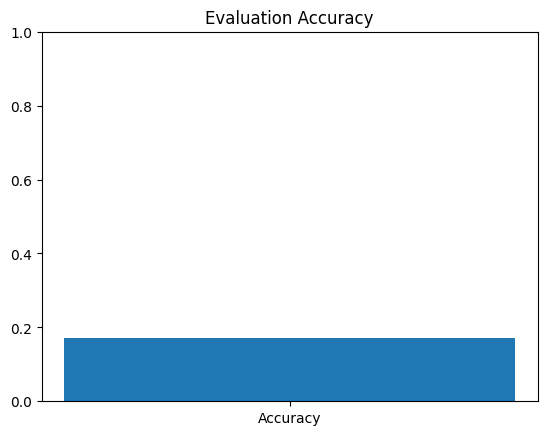

In [ ]:
import matplotlib.pyplot as plt
accuracy = results["eval_accuracy"]

plt.bar(["Accuracy"], [accuracy])
plt.ylim(0, 1)
plt.title("Evaluation Accuracy")
plt.show()

In [ ]:
accuracy

0.17109375

## Second Pretrained try

In [7]:
from transformers import Wav2Vec2Processor

# Load model directly
from transformers import Wav2Vec2FeatureExtractor
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")

In [8]:
resampler = torchaudio.transforms.Resample(orig_freq=48000, new_freq=16000)
def resample(batch):
    arr = torch.tensor(batch["audio"]["array"], dtype=torch.float32)
    batch["audio"]["array"] = resampler(arr).numpy()
    batch["audio"]["sampling_rate"] = 16000
    return batch
dataset = dataset.map(resample, num_proc=4)

Map (num_proc=4):   0%|          | 0/10238 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/2560 [00:00<?, ? examples/s]

In [9]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-large-xlsr-53")
def extract(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=16000, return_tensors="pt", padding=True)
    return {"input_values": inputs.input_values[0], "attention_mask": inputs.attention_mask[0], "label": batch["label"]}
dataset = dataset.map(extract, remove_columns=dataset["train"].column_names)

Map:   0%|          | 0/10238 [00:00<?, ? examples/s]

Map:   0%|          | 0/2560 [00:00<?, ? examples/s]

In [10]:
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


In [11]:
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=feature_extractor, padding=True)

In [12]:
num_labels = len(set(dataset["train"]["label"]))

In [13]:
from transformers import Wav2Vec2ForSequenceClassification
import torch.nn as nn

# Load model
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    "facebook/wav2vec2-large-xlsr-53",
    num_labels=num_labels,
    gradient_checkpointing=True,
    attention_dropout=0.1,
    hidden_dropout=0.1,
    layerdrop=0.1,
    feat_proj_dropout=0.0,
    mask_time_prob=0.05,
    mask_feature_prob=0.0,
    mask_time_length=10,
    mask_feature_length=10,
)

#unfreeze the entire wav2vec2 backbone
for param in model.wav2vec2.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(128, num_labels)
)




config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-large-xlsr-53 and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
#training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    eval_strategy ="steps",
    output_dir="./wav2vec2-emotion",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    gradient_accumulation_steps=4,  #increased for potentially faster training
    warmup_steps=250,  #reduced for potentially faster training
    num_train_epochs=3,
    save_steps=500,
    eval_steps=1000,  #increased (evaluate less frequently)
    logging_steps=500,
    save_total_limit=2,
    fp16=True,
    push_to_hub=False,
)

model.safetensors:   0%|          | 0.00/1.27G [00:00<?, ?B/s]

In [15]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
     train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=feature_extractor,  #padding
    data_collator=data_collator,
      compute_metrics=compute_metrics,
)



<ipython-input-15-0d8c0f751227>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [16]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: amerr (amerr-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy
1000,1.381600,1.224109,0.533984


TrainOutput(global_step=1920, training_loss=1.3424894173940023, metrics={'train_runtime': 3190.966, 'train_samples_per_second': 9.625, 'train_steps_per_second': 0.602, 'total_flos': 2.6624657374212163e+18, 'train_loss': 1.3424894173940023, 'epoch': 3.0})

In [17]:
train_results = trainer.evaluate(eval_dataset=dataset["train"])
test_results = trainer.evaluate(eval_dataset=dataset["test"])

In [18]:
# accuracy
train_acc = train_results["eval_accuracy"]
test_acc = test_results["eval_accuracy"]


In [21]:
print("train_acc",train_acc)
print("test_acc",test_acc)

train_acc 0.621312756397734
test_acc 0.601171875


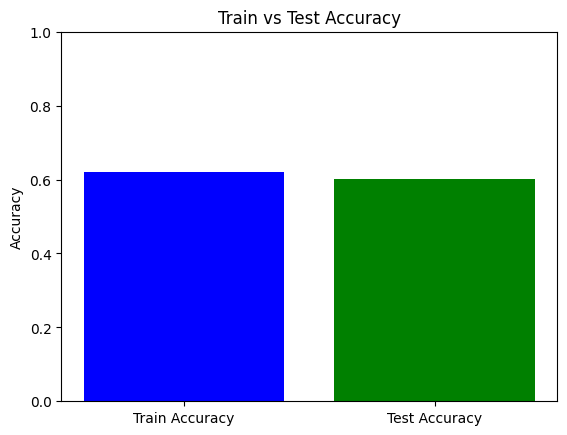

In [20]:
import matplotlib.pyplot as plt
plt.bar(["Train Accuracy", "Test Accuracy"], [train_acc, test_acc], color=["blue", "green"])
plt.ylim(0, 1)
plt.title("Train vs Test Accuracy")
plt.ylabel("Accuracy")
plt.show()

In [23]:
trainer.save_model("./wav2vec2-emotion2")
